# Детекция этикетки вина на фото бутылки (YOLO11)

Ноутбук для Kaggle: скачивает датасет [123 (v1)](https://universe.roboflow.com/romkagrigorev228-gmail-com/123-v9ssk/dataset/1) с Roboflow Universe (353 фото, детекция этикетки на бутылке, CC BY 4.0) и обучает детектор **YOLO11** (ultralytics).

Результат — модель, которая находит на фото прямоугольник этикетки. Это первый шаг пайплайна для сканера вин (ЛЦТ, "Своё Вино"): дальше кроп этикетки уходит в retrieval-модель для сопоставления с карточкой каталога.

**Перед запуском на Kaggle:**
1. Включи GPU: `Settings → Accelerator → GPU T4 x2` (или P100).
2. Включи интернет: `Settings → Internet → On` (нужен для скачивания датасета и весов).
3. Получи приватный API-ключ Roboflow: `roboflow.com → Settings → Roboflow API → Private API Key`.
4. Добавь его как Kaggle Secret: `Add-ons → Secrets → Add a new secret`, имя `ROBOFLOW_API_KEY`, значение — твой ключ. Так ключ не попадёт в код и не утечёт при публикации ноутбука.


## 0. Установка зависимостей и проверка GPU

In [1]:
!pip install -q -U ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 75.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 6.7 MB/s eta 0:00:00


In [4]:
import os
import glob
import yaml
import torch
from ultralytics import YOLO

print("Torch:", torch.__version__)
print("CUDA доступна:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU не найден — включи Settings → Accelerator → GPU в этом ноутбуке.")


Torch: 2.10.0+cu128
CUDA доступна: True
GPU: Tesla T4


## 1. Скачивание датасета с Roboflow

Ключ читается из Kaggle Secrets (`ROBOFLOW_API_KEY`). Если секрет не настроен, ноутбук попросит ввести ключ вручную (не сохраняется в файле).

In [5]:
api_key = None
try:
    from kaggle_secrets import UserSecretsClient
    api_key = 'QSqW4uOSflrlgAAKw12d'
    print("Ключ получен из Kaggle Secrets.")
except Exception:
    pass

if not api_key:
    import getpass
    api_key = getpass.getpass("Введи приватный Roboflow API key: ")


Ключ получен из Kaggle Secrets.


In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key=api_key)
project = rf.workspace("romkagrigorev228-gmail-com").project("123-v9ssk")
version = project.version(1)

# формат "yolov11" отдаёт разметку в формате YOLOv8/v11 (совместимы) + data.yaml
dataset = version.download("yolov11", location="/kaggle/working/dataset")

DATASET_DIR = dataset.location
print("Датасет скачан в:", DATASET_DIR)


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/dataset in yolov11:: 100%|██████████| 711/711 [00:00<00:00, 10101.04it/s]

Датасет скачан в: /kaggle/working/dataset


## 2. Обзор датасета

In [7]:
data_yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(data_yaml_path) as f:
    data_cfg = yaml.safe_load(f)

print(yaml.dump(data_cfg, allow_unicode=True, sort_keys=False))

for split in ("train", "val", "test"):
    key = split if split in data_cfg else {"train": "train", "val": "val", "test": "test"}.get(split)
    split_path = data_cfg.get(key)
    if split_path:
        img_dir = os.path.normpath(os.path.join(DATASET_DIR, split_path))
        n = len(glob.glob(os.path.join(img_dir, "*")))
        print(f"{split}: {img_dir} — {n} файлов")


train: ../train/images
val: ../valid/images
test: ../test/images
nc: 2
names:
- bottle
- label
roboflow:
  workspace: romkagrigorev228-gmail-com
  project: 123-v9ssk
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/romkagrigorev228-gmail-com/123-v9ssk/dataset/1

train: /kaggle/working/train/images — 0 файлов
val: /kaggle/working/valid/images — 0 файлов
test: /kaggle/working/test/images — 0 файлов


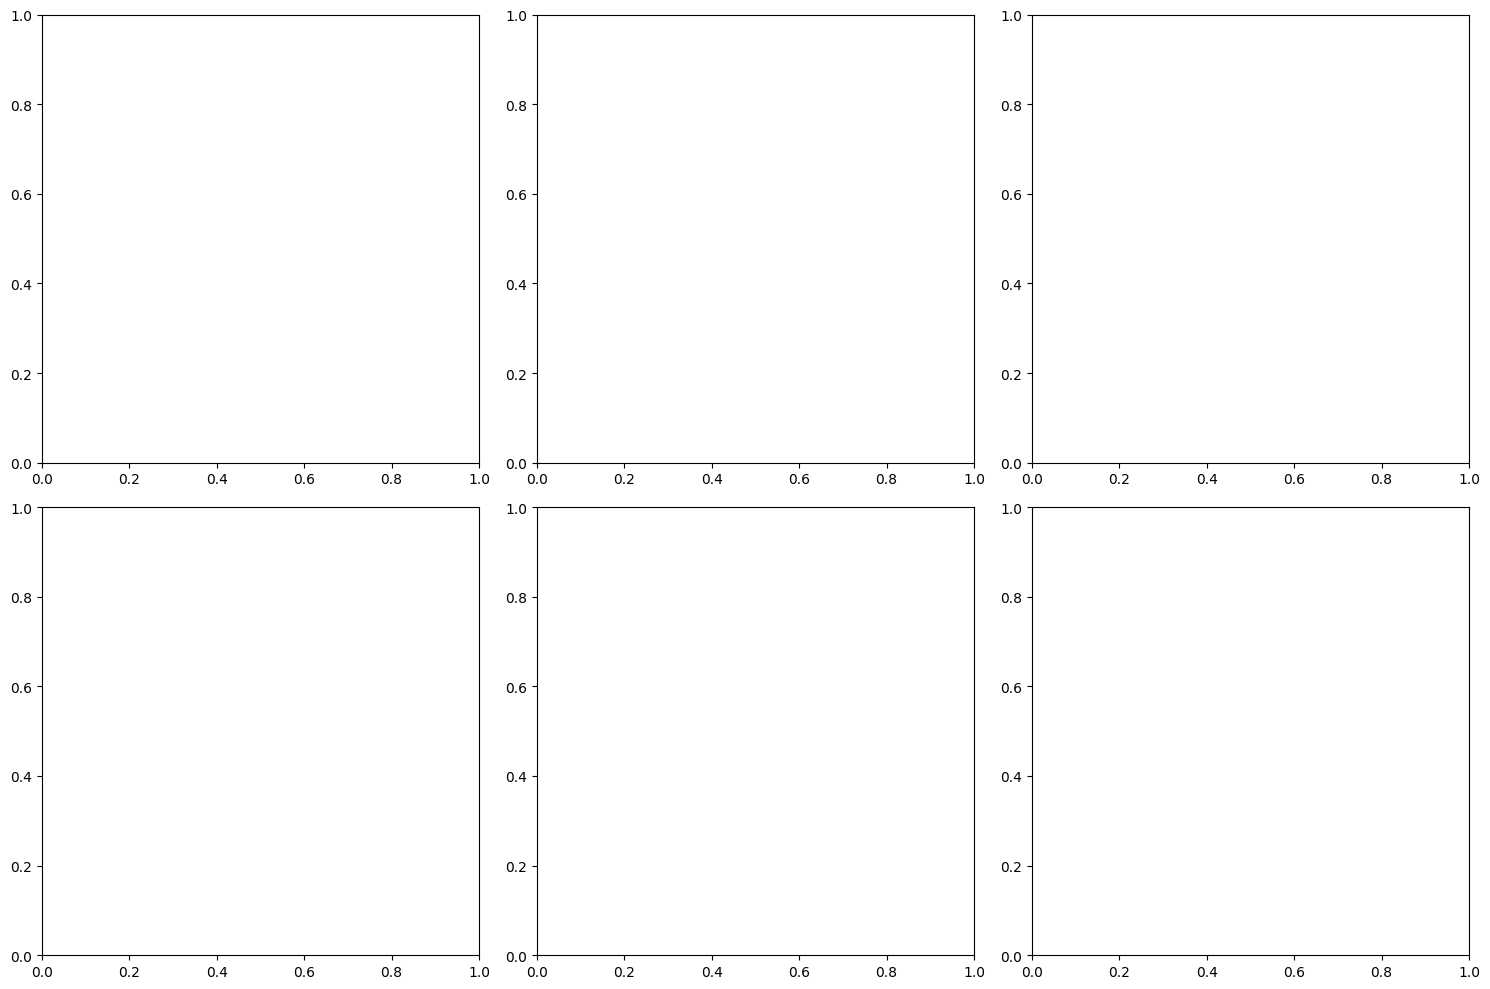

In [8]:
import cv2
import matplotlib.pyplot as plt

def show_samples(images_dir, labels_dir, class_names, n=6):
    img_paths = sorted(glob.glob(os.path.join(images_dir, "*")))[:n]
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, img_path in zip(axes.flat, img_paths):
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        label_path = os.path.join(labels_dir, os.path.splitext(os.path.basename(img_path))[0] + ".txt")
        if os.path.exists(label_path):
            with open(label_path) as f:
                for line in f:
                    cls, xc, yc, bw, bh = map(float, line.split())
                    x1 = int((xc - bw / 2) * w)
                    y1 = int((yc - bh / 2) * h)
                    x2 = int((xc + bw / 2) * w)
                    y2 = int((yc + bh / 2) * h)
                    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
                    cv2.putText(img, class_names[int(cls)], (x1, max(y1 - 10, 0)),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
        ax.imshow(img)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

train_images_dir = os.path.normpath(os.path.join(DATASET_DIR, data_cfg["train"]))
train_labels_dir = train_images_dir.replace("images", "labels")
show_samples(train_images_dir, train_labels_dir, data_cfg["names"])


## 3. Обучение YOLO11

Датасет маленький (247 train / 71 val / 35 test), поэтому:
- берём **yolo11n** (nano) — меньше риск переобучения, быстрее обучается на Kaggle GPU;
- используем предобученные COCO-веса (transfer learning) и умеренную аугментацию, которую даёт ultralytics по умолчанию;
- `patience=20` — ранняя остановка, чтобы не переобучиться при небольшом числе изображений;
- при необходимости замени `yolo11n.pt` на `yolo11s.pt`, если после первого прогона видно, что модели не хватает ёмкости (недообучение).

In [9]:
model = YOLO("yolo11s.pt")

results = model.train(
    data=data_yaml_path,
    epochs=100,
    patience=20,
    imgsz=640,
    batch=16,
    device=0,
    project="/kaggle/working/runs",
    name="wine_label_yolo11n",
    seed=0,
    plots=True,
)


Ultralytics 8.4.159 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=wine_label_yolo11n, nbs=64, nms=None, ops

`get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.


      2/100      5.03G     0.7186     0.8326      1.239         36        640: 100% ━━━━━━━━━━━━ 16/16 5.6it/s 2.9s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 5.9it/s 0.5s0.4s
                   all         71        142       0.29      0.437      0.256      0.122

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      3/100      5.03G     0.6831     0.7579      1.218         35        640: 100% ━━━━━━━━━━━━ 16/16 5.7it/s 2.8s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.0it/s 0.5s0.4s
                   all         71        142      0.506     0.0282    0.00161   0.000414

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      4/100      5.03G     0.7599     0.7108      1.258         35        640: 100% ━━━━━━━━━━━━ 16/16 5.7it/s 2.8s0.2s
                 Class     Images  Instances  

## 4. Метрики на валидации и тесте

In [10]:
val_metrics = model.val(data=data_yaml_path, split="val")
print("mAP50:", val_metrics.box.map50)
print("mAP50-95:", val_metrics.box.map)
print("Precision:", val_metrics.box.mp)
print("Recall:", val_metrics.box.mr)


Ultralytics 8.4.159 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 858.5±310.1 MB/s, size: 28.2 KB)
val: Scanning /kaggle/working/dataset/valid/labels.cache... 71 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 29.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.2it/s 2.3s0.7s
                   all         71        142      0.999      0.999      0.995      0.964
                bottle         71         71      0.997          1      0.995      0.987
                 label         71         71          1      0.999      0.995      0.941
Speed: 4.3ms preprocess, 10.2ms inference, 0.0ms loss, 6.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
mAP50: 0.995
mAP50-95: 0.9637983266273192
Precision: 0.9987384764093534
Recall: 0.999

In [11]:
test_metrics = model.val(data=data_yaml_path, split="test")
print("Test mAP50:", test_metrics.box.map50)
print("Test mAP50-95:", test_metrics.box.map)


Ultralytics 8.4.159 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 658.3±236.8 MB/s, size: 25.0 KB)
val: Scanning /kaggle/working/dataset/test/labels... 35 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 35/35 1.2Kit/s 0.0s
val: New cache created: /kaggle/working/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 1.9it/s 1.6s1.1s
                   all         35         70      0.998          1      0.995      0.976
                bottle         35         35      0.997          1      0.995       0.99
                 label         35         35      0.998          1      0.995      0.963
Speed: 5.7ms preprocess, 18.1ms inference, 0.1ms loss, 3.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
Test mAP50: 0.995
Test mA

## 5. Инференс на тестовых изображениях


WARNING ⚠️ imgsz=[720] must be multiple of max stride 32, updating to [736]
0: 736x736 1 bottle, 1 label, 16.1ms
1: 736x736 1 bottle, 1 label, 16.1ms
2: 736x736 1 bottle, 1 label, 16.1ms
3: 736x736 1 bottle, 1 label, 16.1ms
4: 736x736 2 bottles, 1 label, 16.1ms
5: 736x736 1 bottle, 1 label, 16.1ms
Speed: 3.0ms preprocess, 16.1ms inference, 0.9ms postprocess per image at shape (1, 3, 736, 736)


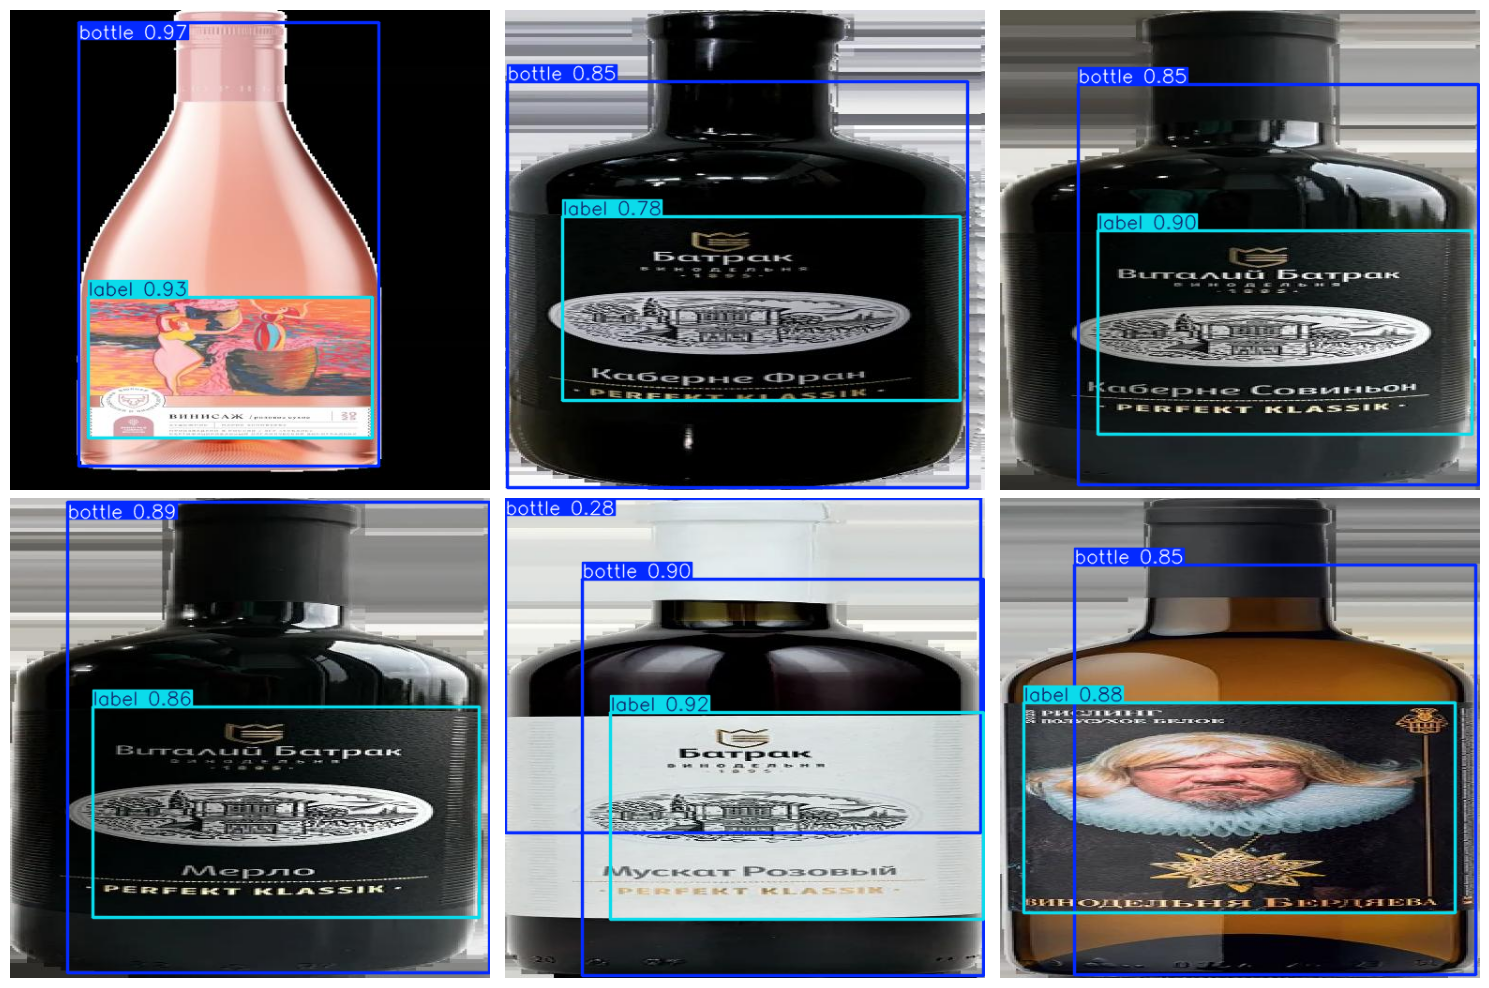

In [15]:
test_images_dir = '/kaggle/working/dataset/test/images/'
test_images = sorted(glob.glob(os.path.join(test_images_dir, "*")))[:6]

preds = model.predict(source=test_images, imgsz=640, conf=0.25, save=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, r in zip(axes.flat, preds):
    ax.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
    ax.axis("off")
plt.tight_layout()
plt.show()


## 6. Сохранение весов

In [ ]:
import shutil

best_weights = os.path.join("/kaggle/working/runs/wine_label_yolo11n/weights/best.pt")
output_weights = "/kaggle/working/wine_label_yolo11n_best.pt"
shutil.copy(best_weights, output_weights)
print("Веса сохранены:", output_weights)

# опционально: экспорт в ONNX для инференса вне ultralytics
# model.export(format="onnx", imgsz=640)


## Дальше: кроп этикетки для retrieval-пайплайна

Функция ниже берёт фото, находит этикетку с наибольшей уверенностью и возвращает вырезанный кроп — его уже можно подавать в модель сопоставления с каталогом (~1500-2000 вин).

In [ ]:
def detect_and_crop_label(image_path, model, conf=0.25):
    img = cv2.imread(image_path)
    result = model.predict(source=image_path, imgsz=640, conf=conf, verbose=False)[0]
    if len(result.boxes) == 0:
        return None
    best_box = max(result.boxes, key=lambda b: float(b.conf[0]))
    x1, y1, x2, y2 = map(int, best_box.xyxy[0].tolist())
    return img[y1:y2, x1:x2]

# пример:
# crop = detect_and_crop_label(test_images[0], model)
# plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)); plt.axis("off"); plt.show()
